# Steel Production – Regression Model v2
This notebook replaces the RandomForestRegressor with **XGBoost** (Extreme Gradient Boosting),
a more powerful algorithm that builds trees sequentially, each correcting the errors of the previous one.

In [1]:
# ── Step 1: Import all required libraries ──────────────────────────────────────
import os                                    # for directory creation
import pandas as pd                          # for loading and handling table data
import numpy as np                           # for numerical operations
import matplotlib.pyplot as plt             # for plotting graphs
from xgboost import XGBRegressor             # XGBoost regression model
from sklearn.model_selection import train_test_split # splits data into train/test
from sklearn.metrics import mean_squared_error, r2_score  # measures model quality

In [2]:
# ── Step 2: Load the CSV file ───────────────────────────────────────────────────
# pd.read_csv() reads a CSV file and returns a DataFrame (a table-like structure)
DATA_PATH = "../../data/processed/normalized_train_data.csv"
df = pd.read_csv(DATA_PATH)

# Show the first 5 rows so we can inspect the data
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 7642 rows, 22 columns


,output,input1,input2,input3,input4,input5,input6,input7,input8,input9,...,input12,input13,input14,input15,input16,input17,input18,input19,input20,input21
0,0.364444,0.0,0.570312,0.778443,0.543058,0.538462,0.621350,0.314136,0.634801,0.667774,...,0.566327,0.583333,0.361702,0.275362,0.107744,0.247059,0.063545,0.079330,0.496855,0.511770
1,0.408889,0.0,0.574219,0.784431,0.532513,0.538462,0.645285,0.418848,0.602578,0.634551,...,0.515306,0.277778,0.297872,0.275362,0.090909,0.200000,0.063545,0.081564,0.484277,0.450741
2,0.431111,0.0,0.589844,0.782934,0.534271,0.538462,0.645285,0.261780,0.624060,0.568106,...,0.553571,0.388889,0.297872,0.275362,0.090909,0.211765,0.063545,0.082682,0.471698,0.485615
3,0.440000,0.0,0.580078,0.782934,0.532513,0.538462,0.645285,0.261780,0.613319,0.601329,...,0.642857,0.388889,0.340426,0.275362,0.090909,0.258824,0.063545,0.083799,0.471698,0.572799
4,0.422222,0.0,0.589844,0.796407,0.525483,0.538462,0.645285,0.261780,0.613319,0.568106,...,0.655612,0.444444,0.340426,0.347826,0.090909,0.223529,0.063545,0.083799,0.471698,0.564080


In [3]:
# ── Step 3: Separate input features (X) and output target (y) ──────────────────
# The first column 'output' is what we want to predict (the target)
# All other columns are the input parameters the model learns from
y = df["output"]               # target column – the value we want to predict
X = df.drop("output", axis=1)  # all remaining columns – the input features

print(f"Input features (X): {X.shape[1]} columns")
print(f"Target values  (y): {y.shape[0]} rows")

Input features (X): 21 columns
Target values  (y): 7642 rows


In [ ]:
# ── Step 4: Split data into training set and test set ──────────────────────────
# We train the model on 80 % of the data and evaluate it on the remaining 20 %.
# random_state=18 ensures the split is the same every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 6113
Test samples     : 1529


In [ ]:
# ── Step 5: Create and train the XGBoost model ─────────────────────────────────
# XGBRegressor (Extreme Gradient Boosting) builds many decision trees sequentially.
# Each new tree learns to correct the mistakes of all previous trees.
#
# n_estimators=500      → number of trees to build
# learning_rate=0.05    → how much each tree contributes to the final prediction
#                         (smaller = more careful learning, needs more trees)
# max_depth=6           → maximum depth of each tree
#                         (deeper = more complex patterns, but risk of overfitting)
# subsample=0.8         → each tree trains on a random 80 % of the training rows
#                         (reduces overfitting)
# colsample_bytree=0.8  → each tree uses a random 80 % of the input features
#                         (reduces overfitting, similar to RandomForest)
# random_state=18       → makes results reproducible
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=18,
)

# model.fit() is the actual training step –
# the model learns the relationship between X_train and y_train
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [6]:
# ── Step 6: Make predictions and evaluate model quality ────────────────────────
# model.predict() uses the trained model to predict output values for the test set
y_pred = model.predict(X_test)

# RMSE (Root Mean Squared Error): average prediction error in the same unit as y.
# Lower is better. A value of 0 would mean perfect predictions.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² Score: how much of the variance in y is explained by the model.
# 1.0 = perfect, 0.0 = no better than guessing the mean, <0 = worse than mean.
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.4f}  (average prediction error)")
print(f"R²   : {r2:.4f}  (1.0 = perfect fit)")

RMSE : 0.0615  (average prediction error)
R²   : 0.4308  (1.0 = perfect fit)


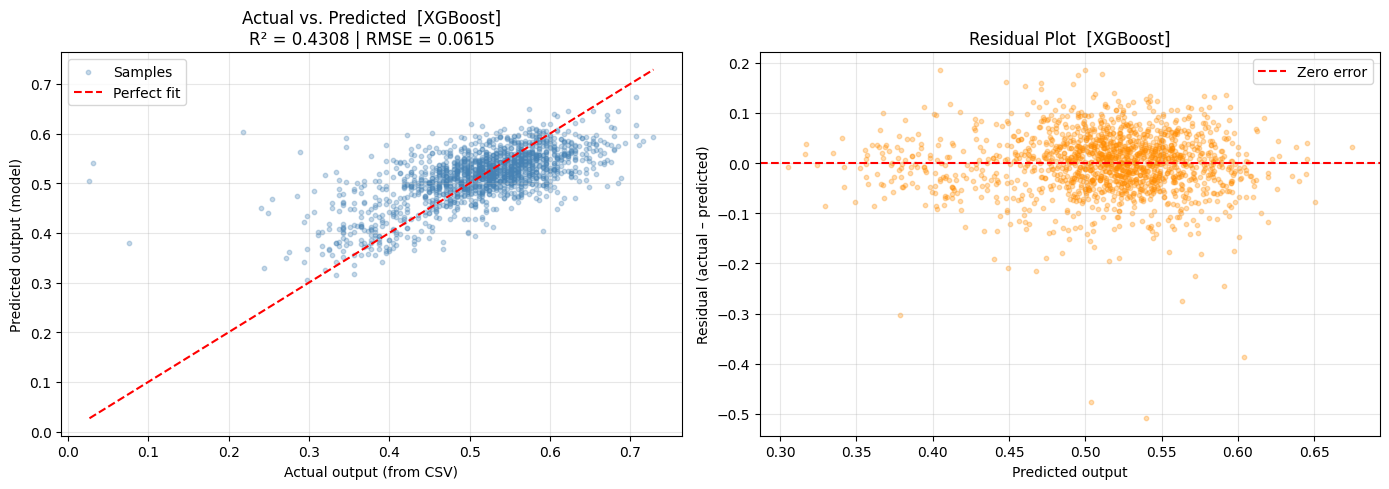

Plot saved to results/figures/actual_vs_predicted_v2.png


In [7]:
# ── Step 7: Plot – Actual vs. Predicted values ─────────────────────────────────
# Each point represents one sample from the test set.
# x-axis = the true output value from the CSV
# y-axis = the value predicted by our model
# A perfect model would place all points exactly on the diagonal line.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left plot: Scatter plot of actual vs predicted ──────────────────────────
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="steelblue", label="Samples")

# Draw the ideal diagonal line (perfect prediction)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, color="red", linewidth=1.5, linestyle="--", label="Perfect fit")

ax.set_xlabel("Actual output (from CSV)")
ax.set_ylabel("Predicted output (model)")
ax.set_title(f"Actual vs. Predicted  [XGBoost]\nR² = {r2:.4f} | RMSE = {rmse:.4f}")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Right plot: Residuals (prediction errors) ───────────────────────────────
# residual = actual value – predicted value
# A good model has residuals randomly scattered around 0 (no systematic bias).
residuals = y_test.values - y_pred

ax2 = axes[1]
ax2.scatter(y_pred, residuals, alpha=0.3, s=10, color="darkorange")
ax2.axhline(0, color="red", linewidth=1.5, linestyle="--", label="Zero error")
ax2.set_xlabel("Predicted output")
ax2.set_ylabel("Residual (actual – predicted)")
ax2.set_title("Residual Plot  [XGBoost]")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../results/figures/actual_vs_predicted_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to results/figures/actual_vs_predicted_v2.png")

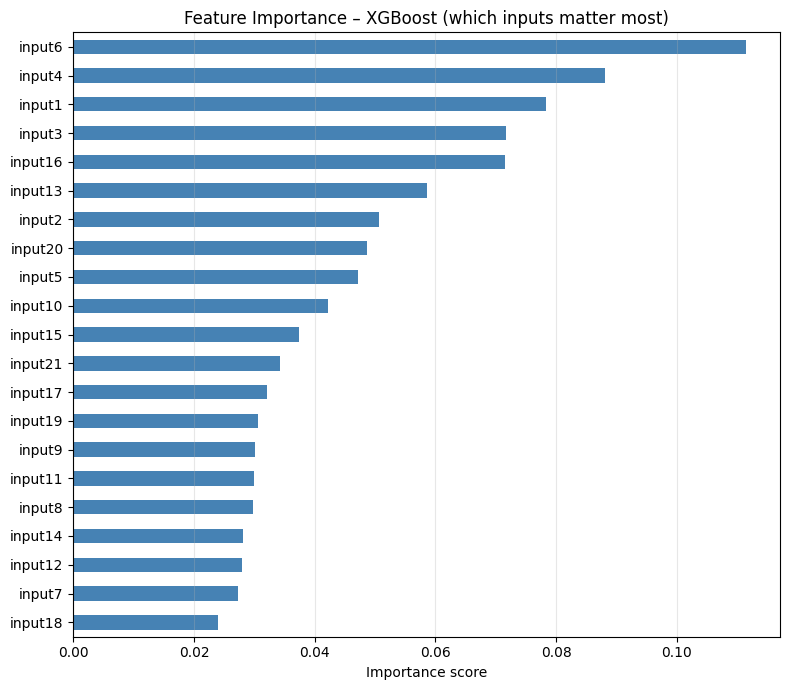

Plot saved to results/figures/feature_importance_v2.png


In [8]:
# ── Step 8: Feature Importance ─────────────────────────────────────────
# XGBoost can tell us which input columns had the most influence on the output.
# A higher importance value means that feature was more useful for predicting output.
importances = pd.Series(model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importances_sorted.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance – XGBoost (which inputs matter most)")
ax.set_xlabel("Importance score")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../../results/figures/feature_importance_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to results/figures/feature_importance_v2.png")